# Total variance production

This notebook looks to explain variance production over a single timestep in two ANU-TUB configurations.
Both use a z-star vertical coordindate and both have background diffusivity $2\times 10^{-5}$.
The difference is in horizontal resolution: one is 0.25 and the is 1 degree.

In the 1 degree run, there is horizontal diffusion derived from MEKE whereas in the 0.25 degree run there is not.
We have alread shown that we can approximately balance the variance production between the advection scheme + mixing and surface forcing.
This notebook is trying to do the same thing for a whole day of output at both resolutions.

In [10]:
tub_output_dir = "/g/data/e14/jb2381/one-degree-anu-tub/output"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/one-degree-anu-tub/output`
[ Info: Plotting and analysis environment setup!
[ Info: Experiments in the catalogue are: ("zstar", "hycom1", "adapt", "alt-hycom", "zstar-weaker-KD", "hycom1-weaker-KD", "adapt-weaker-KD", "alt-hycom-weaker-KD")
┌ Info: Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [63]:
quart_deg = "/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-zstar/output016/ocean_hour.nc"
quart_static_deg = "/g/data/e14/jb2381/anu-tub/outputs/anu-tub-nm-zstar/output016/ocean_static.nc"
one_deg = joinpath(pwd(), "zstar/output057/ocean_hour.nc")
one_static_deg = joinpath(pwd(), "zstar/output057/ocean_static.nc")

"/g/data/e14/jb2381/one-degree-anu-tub/output/zstar/output057/ocean_static.nc"

In [24]:
"""
    function T_global_mean(output::AbstractString, static::AbstractString)
Compute the global mean of the temperature field at all timesteps in `output`.
"""
function T_global_mean(output::AbstractString, static::AbstractString)
    
    ds = NCDataset(static, maskingvalue=NaN)
    dA = ds["areacello"][:, :]
    close(ds)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    θ̄ = zeros(Float64, n)
    for t ∈ 1:n
        θ = ds["thetao"][:, :, :, t]
        dV = ds["thkcello"][:, :, :, t]
        for k ∈ axes(dV, 3)
            dV[:, :, k] .*= dA
        end
        θ .*= dV
        θ̄[t] = nansum(θ) / nansum(dV)
    end
    close(ds)
    
    return dA, θ̄
end
function T_global_mean(output::AbstractString, dA::AbstractArray)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    θ̄ = zeros(Float64, n)
    for t ∈ 1:n
        θ = ds["thetao"][:, :, :, t]
        dV = ds["thkcello"][:, :, :, t]
        for k ∈ axes(dV, 3)
            dV[:, :, k] .*= dA
        end
        θ .*= dV
        θ̄[t] = nansum(θ) / nansum(dV)
    end
    close(ds)
    
    return θ̄
end

T_global_mean (generic function with 2 methods)

In [69]:
"""
    function variance_production(output::AbstractString, static::AbstractString)
Return all variables contributing to variance production over a timestep. The variables
have been globally integrated so the balance between production and destruction can
be assessed.
"""
function variance_production(output::AbstractString, static::AbstractString; dt = 3600)
    
    vp = Dict{Any, Any}()
    
    ds = NCDataset(static, maskingvalue=NaN)
    dA = ds["areacello"][:, :]
    close(ds)
    
    vp["dA"] = dA
    θ̄ = T_global_mean(output, dA)
    
    ds = NCDataset(output, maskingvalue=NaN)
    n = ds.dim["time"]
    asvp = zeros(Float64, n)
    diffvp = zeros(Float64, n)
    hordiffvp = zeros(Float64, n)
    remapvp = zeros(Float64, n)
    
    # thickness weighted variables
    for t ∈ 1:n
        _asvp = ds["T_advection_scheme_variance_production"][:, :, :, t]
        _diffvp = ds["T_diabatic_diff_var_prod"][:, :, :, t]
        _rempavp = ds["T_remap_variance_production"][:, :, :, t]
        _hordiffvp = ds["T_hordiff_variance_production"][:, :, :, t]
        for k ∈ axes(_asvp, 3)
            _asvp[:, :, k] .*= dA
            _diffvp[:, :, k] .*= dA
            _rempavp[:, :, k] .*= dA
            _hordiffvp[:, :, k] .*= dA
        end
        asvp[t] = nansum(_asvp)
        diffvp[t] = nansum(_diffvp)
        remapvp[t] = nansum(_rempavp)
        hordiffvp[t] = nansum(_hordiffvp)
    end
    
    # offline calculations
    bfvp = zeros(Float64, n)
    total_var = zeros(Float64, n-1)
    for t ∈ 1:n
        # variance production from surface forcing
        h_post_foricng = ds["boundary_forcing_h"][:, :, :, t] 
        h_pre_forcing = h_post_foricng .- dt*(ds["boundary_forcing_h_tendency"][:, :, :, t])
        θ_predia = ds["temp_predia"][:, :, :, t]
        θ_post_forcing = θ_predia .+ dt*(ds["boundary_forcing_temp_tendency"][:, :, :, t])

        _bfvp = h_post_foricng .* (θ_post_forcing .- θ̄[t]).^2 
        _bfvp .-= h_pre_forcing .* (θ_predia .- θ̄[t]).^2
        for k ∈ axes(_bfvp, 3)
            _bfvp[:, :, k] .*= dA
        end
        bfvp[t] = nansum(_bfvp) ./ dt
        
        # total change in tmeperature variance over timestep
        if t < n
            _Δhθ² = (ds["thetao"][:, :, :, t+1] .- θ̄[t+1]).^2
            _Δhθ² .*= ds["thkcello"][:, :, :, t+1]
            _Δhθ² .-= ds["thkcello"][:, :, :, t].*(ds["thetao"][:, :, :, t] .- θ̄[t]).^2
            for k ∈ axes( _Δhθ², 3)
                _Δhθ²[:, :, k] .*= dA
            end
            _Δhθ² ./= dt
            total_var[t] = nansum(_Δhθ²)
        end
    end
    
    vp["asvp"] = asvp
    vp["hordiffvp"] = hordiffvp
    vp["diffvp"] = diffvp
    vp["remapvp"] = remapvp
    vp["bfvp"] = bfvp
    vp["total_var"] = total_var
    close(ds)
    
    return vp 
end

variance_production

## Quarter degree

In [81]:
vp = variance_production(quart_deg, quart_static_deg)

Dict{Any, Any} with 7 entries:
  "asvp"      => [-1.28331e9, -1.28418e9, -1.28486e9, -1.28581e9, -1.28703e9, -…
  "dA"        => [8.9288e7 9.00237e7 … 9.00237e7 8.9288e7; 8.9288e7 9.00237e7 ……
  "remapvp"   => [-5.04212e6, -5.03915e6, -4.99697e6, -5.02489e6, -5.0325e6, -5…
  "hordiffvp" => [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0…
  "diffvp"    => [-3.04226e9, -3.04221e9, -3.04202e9, -3.0421e9, -3.04198e9, -3…
  "total_var" => [-7.0294e6, -7.46856e6, -8.27612e6, -9.40761e6, -1.042e7, -1.1…
  "bfvp"      => [4.32821e9, 4.32823e9, 4.32825e9, 4.32828e9, 4.3283e9, 4.32832…

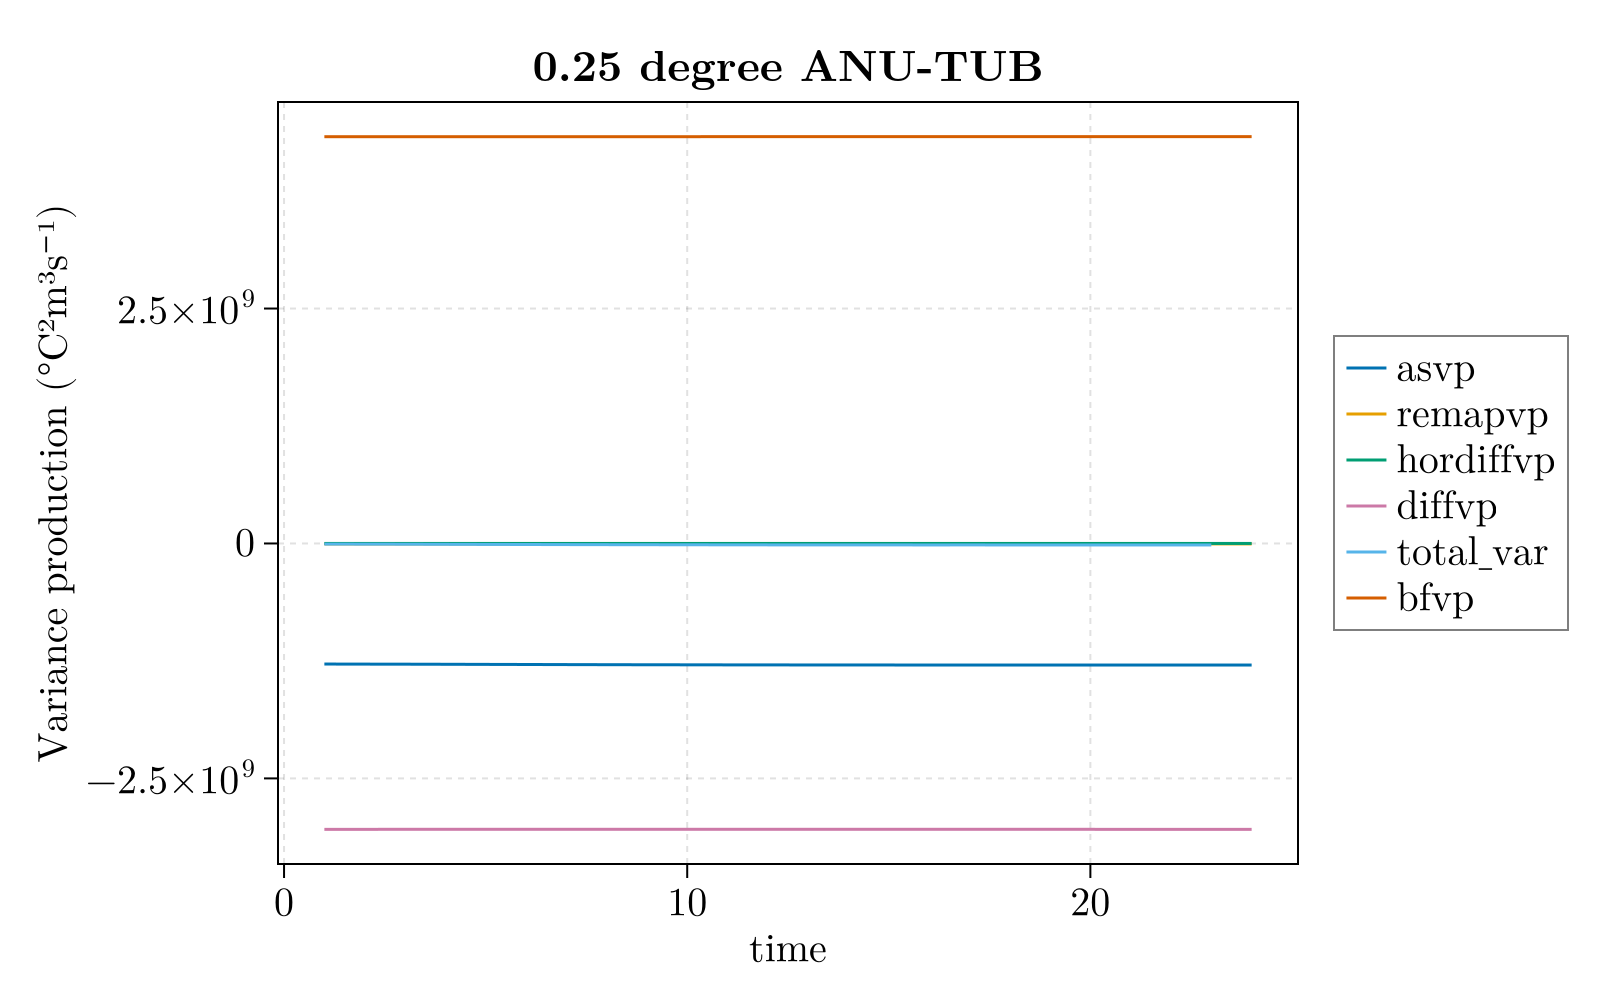

In [82]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "0.25 degree ANU-TUB")
for k ∈ keys(vp)
    if k != "dA"
        lines!(ax, vp[k], label = k)
    end
end
Legend(fig[1, 2], ax)
fig

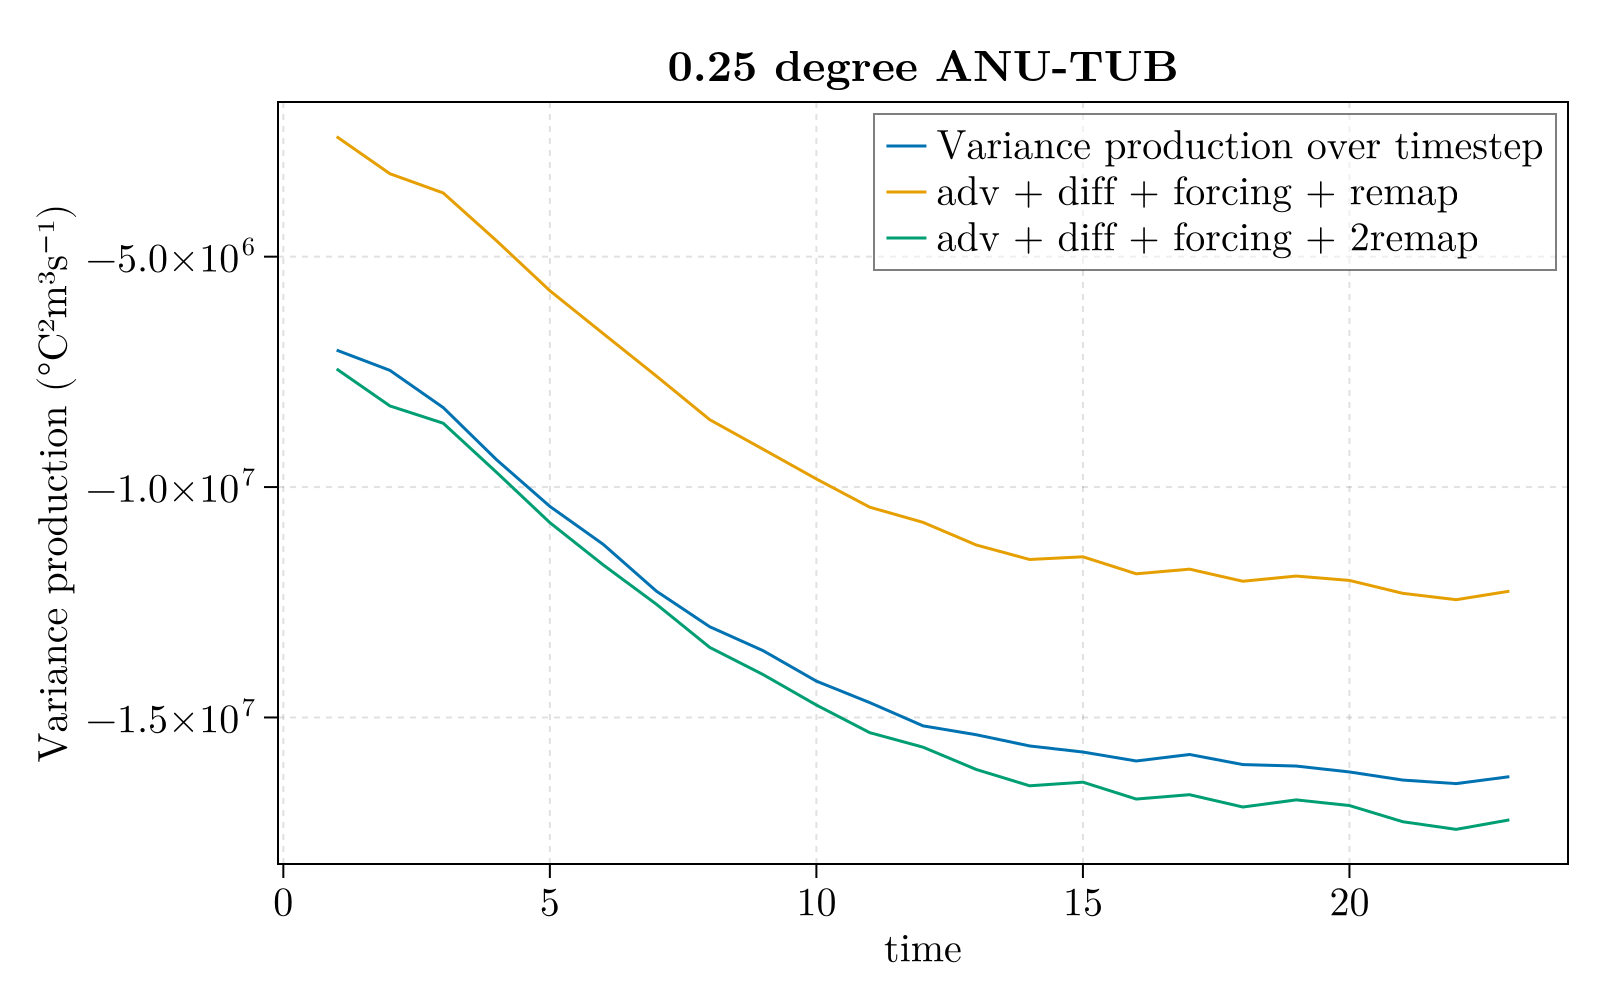

In [91]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "0.25 degree ANU-TUB")
lines!(ax, vp["total_var"], label = "Variance production over timestep")
lines!(ax, vp["diffvp"][1:end-1] .+ vp["asvp"][1:end-1] .+ vp["remapvp"][1:end-1] .+ vp["bfvp"][1:end-1], label = "adv + diff + forcing + remap")
lines!(ax, vp["diffvp"][1:end-1] .+ vp["asvp"][1:end-1] .+ 2*vp["remapvp"][1:end-1] .+ vp["bfvp"][1:end-1], label = "adv + diff + forcing + 2remap")
axislegend(ax, position = :rt)
fig

## One degree

In [84]:
vp_od = variance_production(one_deg, one_static_deg)

Dict{Any, Any} with 7 entries:
  "asvp"      => [-6.34045e8, -6.34555e8, -6.37123e8, -6.36756e8, -6.38981e8, -…
  "dA"        => [1.4463e9 1.49448e9 … 1.49448e9 1.4463e9; 1.4463e9 1.49448e9 ……
  "remapvp"   => [-1.05051e6, -1.08039e6, -1.13638e6, -1.15329e6, -1.15587e6, -…
  "hordiffvp" => [-3.23066e8, -3.2307e8, -3.23071e8, -3.23072e8, -3.23068e8, -3…
  "diffvp"    => [-3.10962e9, -3.11036e9, -3.111e9, -3.11051e9, -3.11032e9, -3.…
  "total_var" => [4.43539e7, 4.11234e7, 4.12818e7, 3.95223e7, 3.97884e7, 4.1389…
  "bfvp"      => [4.19042e9, 4.19058e9, 4.19037e9, 4.19048e9, 4.1902e9, 4.19026…

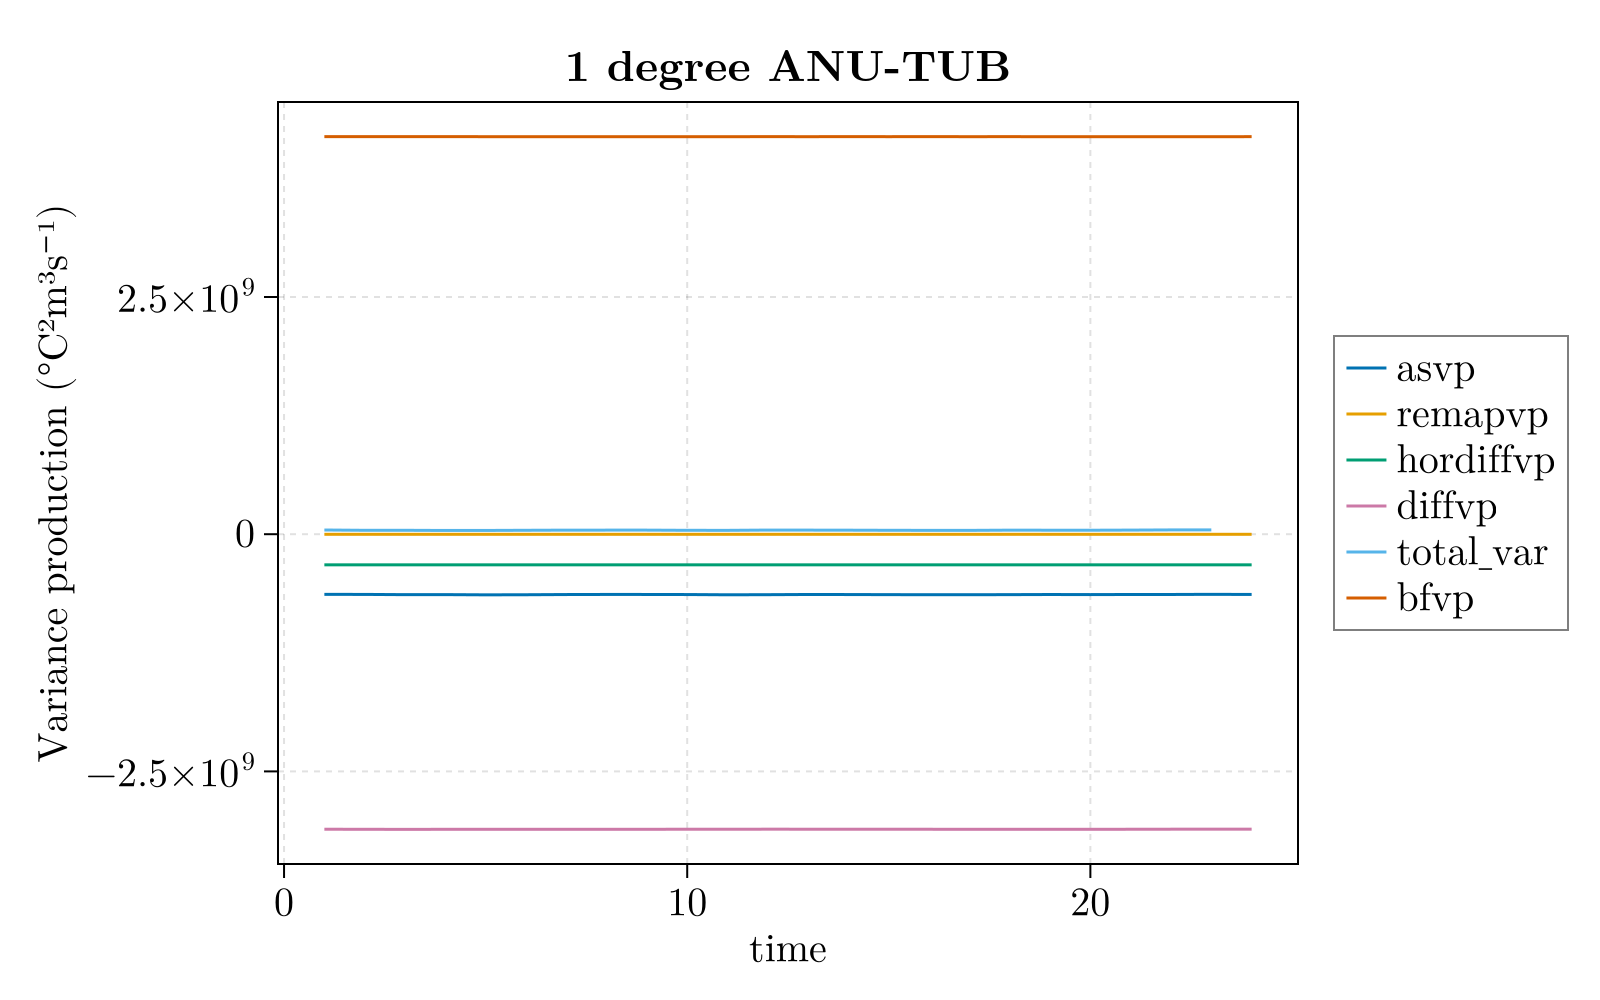

In [92]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "1 degree ANU-TUB")
for k ∈ keys(vp)
    if k != "dA"
        lines!(ax, vp_od[k], label = k)
    end
end
Legend(fig[1, 2], ax)
fig

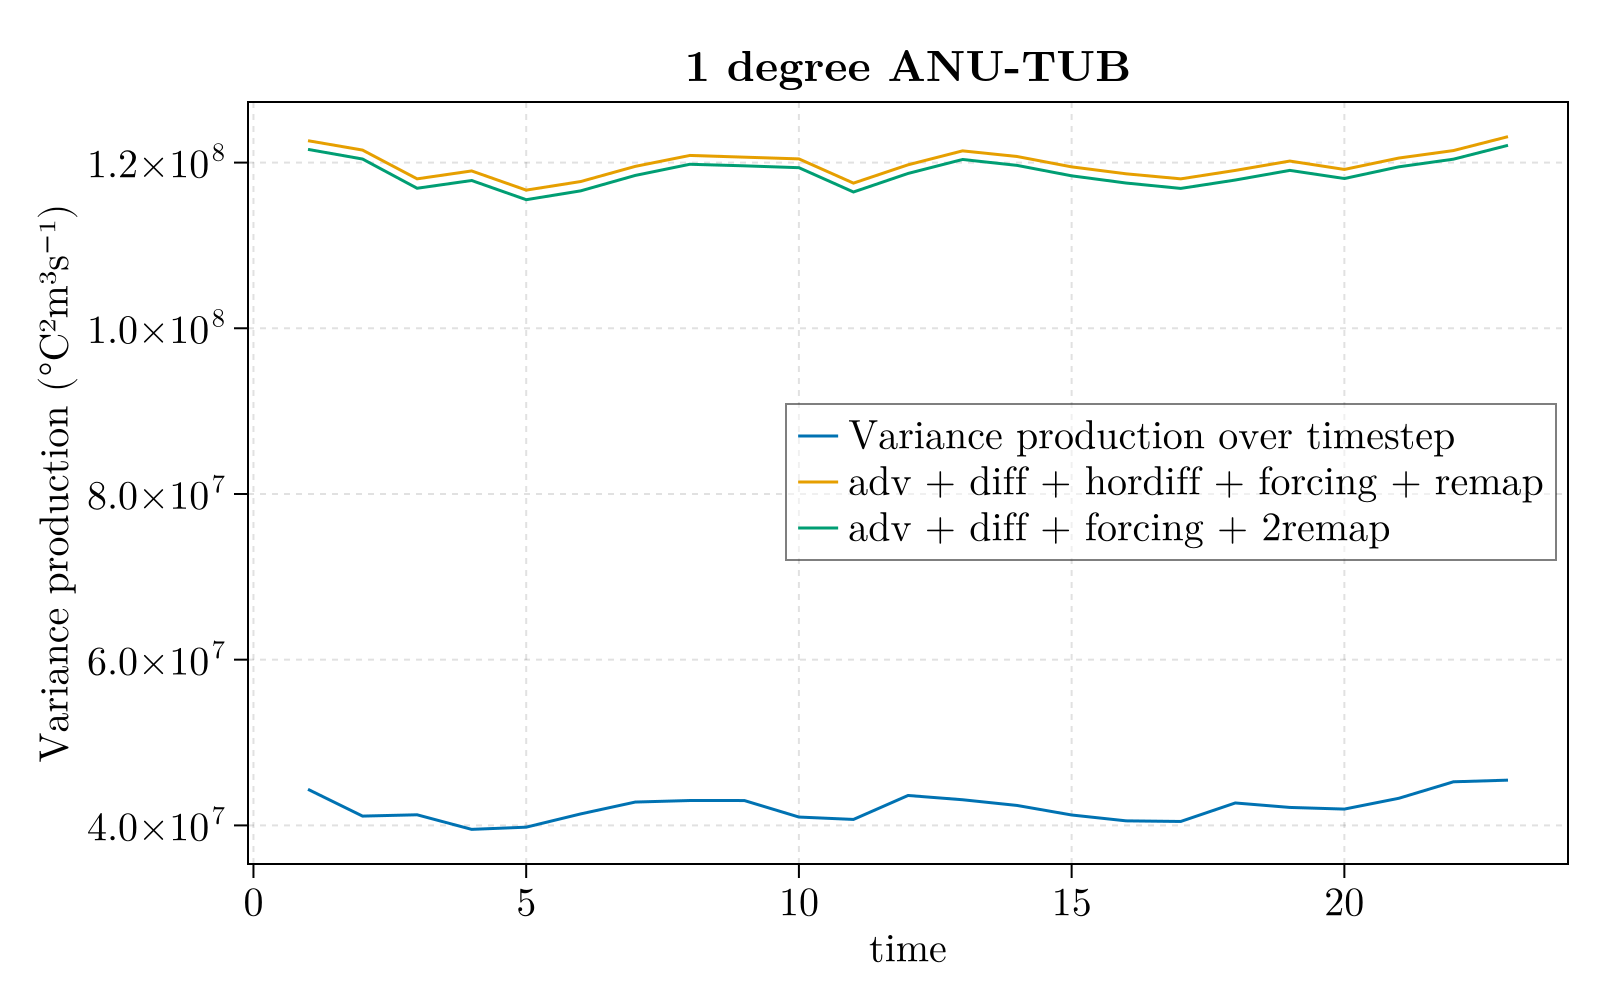

In [116]:
fig = Figure(size = (800, 500))
ax = Axis(fig[1, 1], xlabel = "time", ylabel = "Variance production (°C²m³s⁻¹)", title = "1 degree ANU-TUB")
lines!(ax, vp_od["total_var"], label = "Variance production over timestep")
lines!(ax, vp_od["hordiffvp"][1:end-1] .+ vp_od["diffvp"][1:end-1] .+ vp_od["asvp"][1:end-1] .+ vp_od["remapvp"][1:end-1] .+ vp_od["bfvp"][1:end-1], label = "adv + diff + hordiff + forcing + remap")
lines!(ax, vp_od["hordiffvp"][1:end-1] .+ vp_od["diffvp"][1:end-1] .+ vp_od["asvp"][1:end-1] .+ 2*vp_od["remapvp"][1:end-1] .+ vp_od["bfvp"][1:end-1], label = "adv + diff + forcing + 2remap")
axislegend(ax, position = :rc)
fig